In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg
import numpy as np
from scipy import stats
import os
import smarts_cerebellum.globals as gl
from smarts_cerebellum.util import preprocess_tract_df

In [5]:
CST_T1  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CST_T1_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_GM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CST_GM_mod_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_WM  = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CST_WM_mod_slope.tsv'), sep = '\t')   # slope for each subject at L/R CST
CST_CSF = pd.read_csv(os.path.join(gl.baseDir, 'regression', 'summary_MNISymC_CST_CSF_mod_slope.tsv'), sep = '\t')  # slope for each subject at L/R CST


# t1_r_patients, t1_l_patients, t1_bilat_controls, cst_t1 = preprocess_tract_df(CST_T1)
# wm_r_patients, wm_l_patients, wm_bilat_controls, cst_wm = preprocess_tract_df(CST_WM)
# gm_r_patients, gm_l_patients, gm_bilat_controls, cst_gm = preprocess_tract_df(CST_GM)
# csf_r_patients, csf_l_patients, csf_bilat_controls, cst_csf = preprocess_tract_df(CST_CSF)

In [ ]:
def preprocess_tract_df(df, tract='CST'):
    # cut dataframe: patients left, right; controls bilateral tract (e.g. CST)
    patients = df[df.isPatient == 1]
    controls = df[df.isPatient == 0]

    r_patients = np.array(df[(df.isPatient == 1) & (df.regionname == f'right_{tract}')]['mean'])
    l_patients = np.array(df[(df.isPatient == 1) & (df.regionname == f'left_{tract}')]['mean'])

    controls_tract = controls[controls.regionname.isin([f'left_{tract}', f'right_{tract}'])]
    controls['region_bilat'] = controls.regionname.str.split('_', n=1).str[1]
    controls_bilat = controls.groupby(['subj_id', 'region_bilat']).agg({'mean': 'mean'}).reset_index()
    controls_bilat['isPatient'] = 0

    b_controls = np.array(controls_bilat['mean'])
    patients_lr = patients[patients.regionname.isin([f'left_{tract}', f'right_{tract}'])]
    tract_df = pd.concat([patients_lr, controls_bilat], ignore_index=True)

    return r_patients, l_patients, b_controls, tract_df

In [7]:
new

,image,image_name,frame,region,regionname,volume,atlas,mean,Week,subj_id,ID,Centre,RefT1,age,Gender,isPatient,LesionSide,LesionLocation,handedness,region_bilat
0,1.0,CU_2310_MNISymC_WM_mod_slope_FlipLR.nii.gz,0.0,14.0,left_CST,4631.0,MNISymC.CST.nii,-0.000122,NaN,CU_2310,2310.0,CU,W0,57.0,M,1,left,subcortical,2.0,NaN
1,1.0,CU_2310_MNISymC_WM_mod_slope_FlipLR.nii.gz,0.0,15.0,right_CST,5165.0,MNISymC.CST.nii,-0.003657,NaN,CU_2310,2310.0,CU,W0,57.0,M,1,left,subcortical,2.0,NaN
2,1.0,CU_2538_MNISymC_WM_mod_slope.nii.gz,0.0,14.0,left_CST,4631.0,MNISymC.CST.nii,-0.000328,NaN,CU_2538,2538.0,CU,W0,24.0,M,1,right,mixed,2.0,NaN
3,1.0,CU_2538_MNISymC_WM_mod_slope.nii.gz,0.0,15.0,right_CST,5165.0,MNISymC.CST.nii,-0.014509,NaN,CU_2538,2538.0,CU,W0,24.0,M,1,right,mixed,2.0,NaN
4,1.0,CU_2925_MNISymC_WM_mod_slope_FlipLR.nii.gz,0.0,14.0,left_CST,4631.0,MNISymC.CST.nii,-0.000240,NaN,CU_2925,2925.0,CU,W0,59.0,F,1,left,subcortical,2.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,NaN,NaN,NaN,NaN,bilat_CST,NaN,NaN,-0.000323,NaN,UZP_1006,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,r
90,NaN,NaN,NaN,NaN,bilat_CST,NaN,NaN,0.000232,NaN,UZP_1007,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,l
91,NaN,NaN,NaN,NaN,bilat_CST,NaN,NaN,-0.000265,NaN,UZP_1007,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,r
92,NaN,NaN,NaN,NaN,bilat_CST,NaN,NaN,-0.001185,NaN,UZP_1008,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,l


**t-test for T1 CST: lesion side in patients, controls** 
 t-value: -0.9792804110360508 	 p-value: 0.3316532451976605


**t-test for T1 CST: non-lesion side in patients, controls** 
 t-value: 0.38182528632486457 	 p-value: 0.7040360432901659


**t-test for CST: within patients, left, right hemispheres** 
 t-value: -4.207324808992538 	 p-value: 0.00017067319112679078




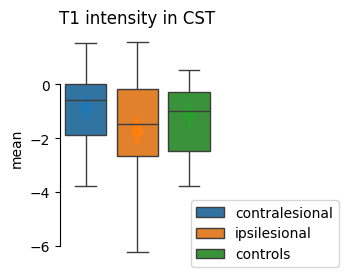

In [3]:
t_val, p_val = stats.ttest_ind(t1_r_patients, t1_bilat_controls)
print(f'**t-test for T1 CST: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(t1_l_patients, t1_bilat_controls)
print(f'**t-test for T1 CST: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_rel(t1_r_patients, t1_l_patients)
print(f'**t-test for CST: within patients, left, right hemispheres** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

fig, ax = plt.subplots(figsize=(2, 3))
sns.boxplot(data=cst_t1, x='regionname', y='mean', hue = 'regionname', showfliers=False)
sns.pointplot(data=cst_t1, x='regionname', y='mean', hue = 'regionname', errorbar='se')

labels = ['contralesional', 'ipsilesional', 'controls']
plt.legend(labels = labels, bbox_to_anchor = (.8, .3))
plt.xticks([])
plt.xlabel(None)

sns.despine(trim = True, bottom=True)
plt.title('T1 intensity in CST')
plt.show()

**t-test for CST: lesion side in patients, controls** 
 t-value: -3.851517158666986 	 p-value: 0.00030413179138631934


**t-test for CST: non-lesion side in patients, controls** 
 t-value: -1.1033650876565908 	 p-value: 0.2745875860323665


**t-test for CST: within patients, left, right hemispheres** 
 t-value: -4.494347663883597 	 p-value: 7.311562721739249e-05




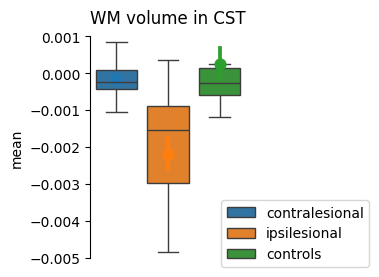

In [5]:
t_val, p_val = stats.ttest_ind(wm_r_patients,wm_bilat_controls)
print(f'**t-test for CST: lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_ind(wm_l_patients,wm_bilat_controls)
print(f'**t-test for CST: non-lesion side in patients, controls** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

t_val, p_val = stats.ttest_rel(wm_r_patients,wm_l_patients)
print(f'**t-test for CST: within patients, left, right hemispheres** \n t-value: {t_val} \t p-value: {p_val}')
print('\n')

fig, ax = plt.subplots(figsize=(2, 3))
sns.boxplot(data=cst_wm, x='regionname', y='mean', hue = 'regionname', showfliers=False)
sns.pointplot(data=cst_wm, x='regionname', y='mean', hue = 'regionname', errorbar='se')

labels = ['contralesional', 'ipsilesional', 'controls']
plt.legend(labels = labels, bbox_to_anchor = (.8, .3))
plt.xticks([])
plt.xlabel(None)

sns.despine(trim = True, bottom=True)
plt.title('WM volume in CST')
plt.show()